# QTRL: Toward Practical Quantum Reinforcement Learning via Quantum-Train

This notebook is a guided demonstration of the QTRL implementation based on MerLin. The goal is to show the data flow from a photonic quantum layer to a classical reinforcement-learning policy, then measure how that policy trains on CartPole.

Original paper: https://arxiv.org/abs/2407.06103
Original code: https://github.com/Hon-Hai-Quantum-Computing/QuantumTrain/tree/chenyu_dev/QuantumTrain

QTRL does not send the CartPole observation through the quantum circuit. Instead, the quantum model generates the parameters of a classical policy. The policy uses those parameters to choose actions, and REINFORCE updates the quantum-model parameters from the episode rewards. The local implementation has documented deviations from the paper; see README.md.

Run this notebook with `papers/QTRL` as the working directory. Install the dependencies with `python -m pip install -r requirements.txt` before running the code cells.

## Original-paper figure to present the model

The image below is from the original QTRL paper. It presents the QTRL framework: a classical reinforcement-learning policy that generates its parameters with a quantum model.

![QTRL framework and results from the original paper](assets/QTRL_model_arxiv_2407-06103.png)

In [35]:
from pathlib import Path

assert Path('lib').is_dir(), 'Run this notebook with papers/QTRL as the working directory.'

import json
import torch
import gymnasium as gym
from lib.util import create_hybrid_model, rl_agent_forward

## Step 1: Initialize the Hybrid Model
We instantiate the repository's Merlin-based hybrid model using `configs/defaults.json`. The model has two conceptual parts:

1. A photonic quantum layer produces `q_output_size` values from the circuit.
2. A classical mapping network transforms those values into the parameters needed by the policy.

For CartPole, the observation has four values and there are two actions. The local policy is linear, so it needs `4 × 2 = 8` generated weights. The TorchQuantum Figure 1 sweep is launched separately from `configs/figure_1-tq.json`.
- State dimension: 4
- Action dimension: 2
- Required weights for the local linear policy: 4 × 2 = 8

The original paper uses larger classical policy topologies. This notebook intentionally demonstrates the current repository API and does not claim paper-equivalent results.

In [36]:
config = json.loads(Path('configs/defaults.json').read_text())
torch.manual_seed(42)

model = create_hybrid_model(config, total_weights_needed=8)
print(f"QTRL {config['backend']} model successfully initialized from configs/defaults.json.")

QTRL merlin_mlp model successfully initialized from configs/defaults.json.


## Step 2: Generate Weights via Quantum Circuit
The forward pass combines the quantum photonic circuit with the classical mapping network. The result is an 8-element vector that is interpreted as a `4 × 2` weight matrix. These are policy parameters, not predictions or actions yet.

The `NaN` check is a numerical sanity check: non-finite generated parameters would make policy inference and gradient updates invalid.

In [37]:
with torch.no_grad():
    generated_weights = model()[0]
    
print(f'Shape of generated weights: {generated_weights.shape}')
print(f'First 8 weights (policy parameters): {generated_weights[:8]}')
print(f'Contains NaN: {torch.isnan(generated_weights).any().item()}')

Shape of generated weights: torch.Size([8])
First 8 weights (policy parameters): tensor([-0.0560,  0.0006, -0.0702, -0.1103,  0.2668,  0.3139, -0.0685, -0.0557])
Contains NaN: False


## Step 3: Load Environment and Prepare Observation
We initialize Gymnasium's `CartPole-v1` environment and obtain one observation. Its four components describe the cart position, cart velocity, pole angle, and pole angular velocity. The environment returns a reward of `1` for every step that the pole remains balanced.

In [38]:
env = gym.make('CartPole-v1')
obs, info = env.reset(seed=42)

print(f'Environment: CartPole-v1')
print(f'Initial observation shape: {obs.shape}')
print(f'Observation: {obs}')

Environment: CartPole-v1
Initial observation shape: (4,)
Observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


## Step 4: Policy Inference
We reshape the generated vector into a `4 × 2` matrix and multiply it by the observation to obtain two action logits. The larger logit corresponds to the action selected by this demonstration. During training, `train_environment` samples from these logits so that REINFORCE can estimate a policy gradient.

In [39]:
# Convert observation to tensor
obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)

# Compute policy logits using generated weights
logits = rl_agent_forward(
    obs_tensor, 
    generated_weights[:8], 
    input_dim=4, 
    output_dim=2
)

# Select action via argmax
action = torch.argmax(logits).item()

print(f'Observation tensor shape: {obs_tensor.shape}')
print(f'Policy logits: {logits}')
print(f'Selected action: {action}')

Observation tensor shape: torch.Size([1, 4])
Policy logits: tensor([[-0.0062,  0.0018]])
Selected action: 1


## Step 5: Execute Step in Environment
We apply the selected action and inspect the transition returned by Gymnasium. A single transition is useful for understanding the interface, but it is not a training result; training requires complete episodes and repeated parameter updates.

In [40]:
next_obs, reward, terminated, truncated, info = env.step(action)

print(f'Action taken: {action}')
print(f'Reward received: {reward}')
print(f'Episode terminated: {terminated}')
print(f'Episode truncated: {truncated}')
print(f'Next observation: {next_obs}')

env.close()
print('\nEnvironment closed. Demonstration complete.')

Action taken: 1
Reward received: 1.0
Episode terminated: False
Episode truncated: False
Next observation: [ 0.02727336  0.18847767  0.03625453 -0.26141977]

Environment closed. Demonstration complete.


## Step 6: Train the Policy and Display the Training Curve
The training helper uses the same Merlin model and CartPole policy for the configured `num_episodes` and `lr` values. For each episode it samples actions, computes the policy-gradient loss from discounted rewards, and updates the hybrid model.

The returned `training_rewards` list contains one total reward per episode. Because CartPole gives one reward per surviving step, higher values mean the pole stayed balanced longer. The plotting helper from `lib.runner` saves the same episode-reward curve produced by the project runner.

Starting training on CartPole-v1 | Required weights : 8
Episode    0 | steps:  16 | reward: 16.00 | Loss: -0.1008
Episode    1 | steps:  18 | reward: 18.00 | Loss: -0.3339
Episode    2 | steps:  68 | reward: 68.00 | Loss: -0.4418
Episode    3 | steps:  24 | reward: 24.00 | Loss: -0.0529
Episode    4 | steps:  29 | reward: 29.00 | Loss: -0.1967
Episode    5 | steps:  12 | reward: 12.00 | Loss: 0.4134
Episode    6 | steps:  21 | reward: 21.00 | Loss: -0.3319
Episode    7 | steps:  15 | reward: 15.00 | Loss: -0.1749
Episode    8 | steps:  25 | reward: 25.00 | Loss: -0.0149
Episode    9 | steps:  33 | reward: 33.00 | Loss: 0.1078
Episode   10 | steps:  16 | reward: 16.00 | Loss: 0.1991
Episode   11 | steps:  26 | reward: 26.00 | Loss: 1.0167
Episode   12 | steps:  10 | reward: 10.00 | Loss: -0.2236
Episode   13 | steps:  17 | reward: 17.00 | Loss: 0.7899
Episode   14 | steps:  43 | reward: 43.00 | Loss: 0.4271
Episode   15 | steps:  13 | reward: 13.00 | Loss: 0.3969
Episode   16 | steps:  

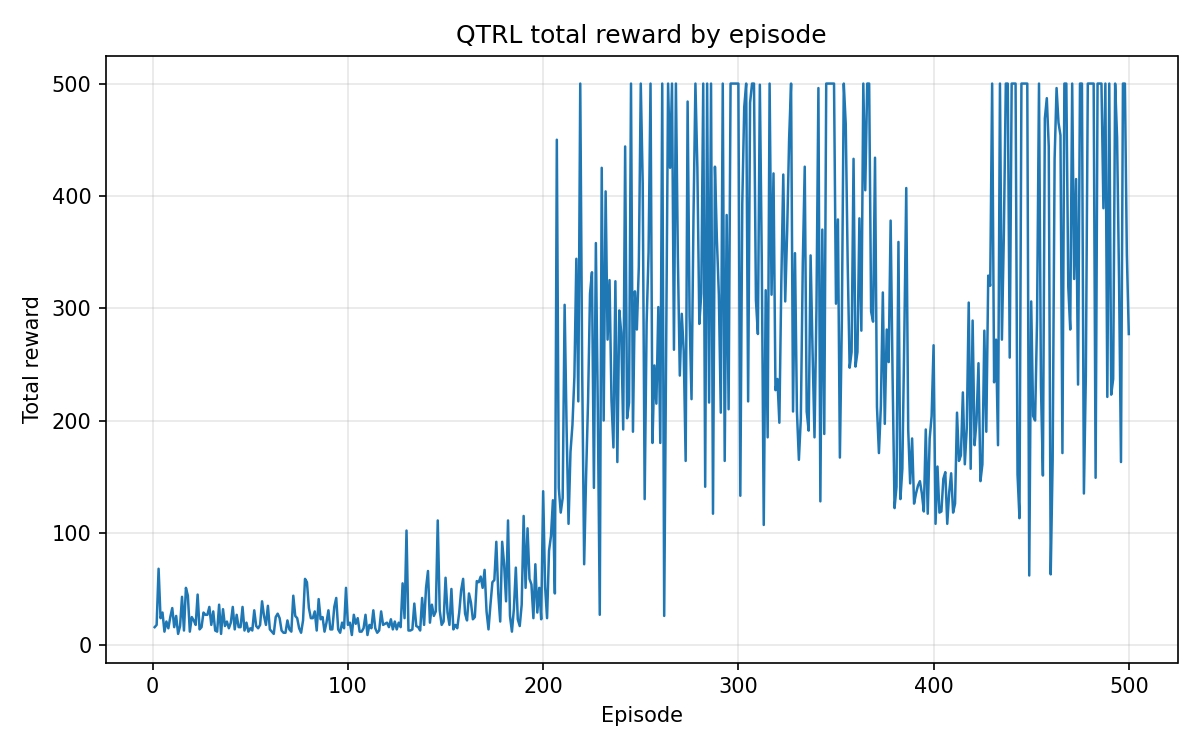

In [41]:
from IPython.display import Image, display
from lib.runner import save_reward_plot
from lib.util import set_global_seed, train_environment

training_seed = 42
training_episodes = int(config['num_episodes'])
training_learning_rate = float(config['lr'])
set_global_seed(seed=training_seed)

training_rewards = train_environment(
    model,
    num_episode=training_episodes,
    learning_rate=training_learning_rate,
    env_name='CartPole-v1',
    seed=training_seed,
)

training_curve_path = Path('outdir/notebook_training_curve.png')
training_curve_path.parent.mkdir(parents=True, exist_ok=True)
save_reward_plot(training_rewards, training_curve_path)
display(Image(filename=str(training_curve_path)))

## Step 7: Interpret the Training Result
The summary below compares the average reward at the beginning and end of training. An increase suggests that the policy is learning to keep the pole balanced for more steps. Reward curves can still be noisy because the policy samples actions and each run uses one random seed. A single curve is therefore evidence of the observed run, not a statistically reliable comparison with the paper.

In [42]:
window_size = 20
early_rewards = training_rewards[:window_size]
late_rewards = training_rewards[-window_size:]

print(f'Configured episodes: {training_episodes}')
print(f'Best episode reward: {max(training_rewards):.2f}')
print(f'Average reward, first {window_size} episodes: {sum(early_rewards) / len(early_rewards):.2f}')
print(f'Average reward, last {window_size} episodes: {sum(late_rewards) / len(late_rewards):.2f}')

Configured episodes: 500
Best episode reward: 500.00
Average reward, first 20 episodes: 25.90
Average reward, last 20 episodes: 389.25
